        date        收盘价      收盘价.1     500收盘价    1000收盘价  000016.SH  \
0 2025-07-18  2764.5160  4058.5486  6099.6104  6552.0741          0   
1 2025-07-21  2772.2385  4085.6072  6161.3086  6612.2589          0   
2 2025-07-22  2792.1823  4118.9582  6213.4072  6637.1035          0   
3 2025-07-23  2801.2002  4119.7685  6196.7577  6607.2200          0   
4 2025-07-24  2812.4428  4149.0368  6293.5984  6701.1200          0   

   000300.SH  000905.SH      000852.SH             PV       nom       PV_DIFF  
0          0        0.0   10514.503843   10514.503843  10000000      0.000000  
1          0        0.0   50363.243582   50363.243582  10000000  39848.739739  
2          0        0.0   68300.469939   68300.469939  10000000  17937.226357  
3          0        0.0   57068.686016   57068.686016  10000000 -11231.783923  
4          0        0.0  108276.029891  108276.029891  10000000  51207.343876  
找到日期: 2025-12-31 00:00:00
D:\Github\chuangxintou D:\Github\chuangxintou\IMAGES\dividend_plot.

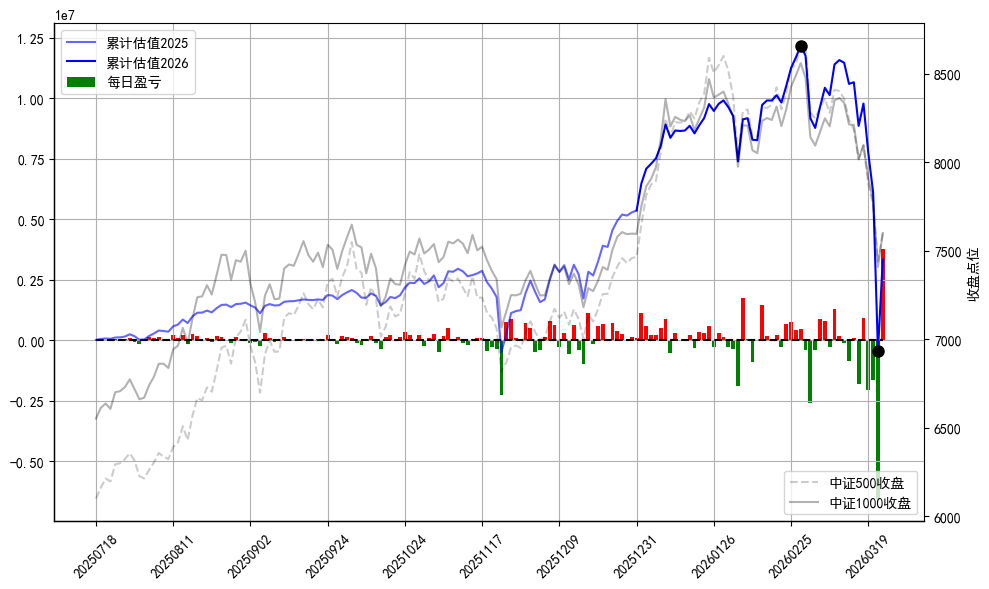

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image, ImageDraw, ImageFont
import datetime
# 设置全局字体和负号显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\Github\chuangxintou'

def maximum_drawdown(prices):
    """
    计算最大回撤及其区间。

    :param prices: 股票价格序列（列表或NumPy数组）
    :return: 最大回撤值和最大回撤区间（开始索引和结束索引）
    """
    # 转换为 NumPy 数组
    prices = np.array(prices)
    
    # 示例使用
    cumulative_sum = prices.cumsum()  # 计算积分

    data =np.array( cumulative_sum)
    # max_dd, (start, end) = maximum_drawdown(prices)

    index_j = np.argmax(np.maximum.accumulate(data) - data)  # 结束位置
    # print(index_j)                      ###maximum loss
    index_i = np.argmax(data[:index_j])  # 开始位置
    # print(index_i)                       ##maximum gain
    d = data[index_j] - data[index_i]  # 最大回撤
    return(d, index_i, index_j)

def plot_dividend():

    save_path2 = r"D:\Github\chuangxintou\data.xlsx"

    df = pd.read_excel(save_path2)
    df = pd.DataFrame(df)
    # df['date'] = pd.to_datetime(df['日期'])
    df.rename(columns={'估值': 'PV', '日期':"date" , '名本':"nom"}, inplace=True)
    df['PV_DIFF'] = df['PV'].diff()
    df.loc[0, 'PV_DIFF'] = 0
    print(df.head())


    times_str = []
    tt = df['date']
    for t in tt:
        times_str.append(t.strftime('%Y%m%d'))
    # 查找特定日期
    target_date = '20251231'  # 要寻找的日期
    if target_date in times_str:
        index = times_str.index(target_date)
        found_date = df['date'].iloc[index]
        print(f"找到日期: {found_date}")
    else:
        print("未找到日期 2025-12-31")

    fig = plt.figure(figsize=( 10, 6 ))
    gs = GridSpec(nrows=1, ncols=1)#, width_ratios=[3, 1, 1, 0], height_ratios=[1, 1])

    # 第一个子图：绘制 qdt 列的散点图

    ax1 = fig.add_subplot(gs[0, 0])  # 第一行，占据前 3 列ax3 = fig.add_subplot(2,1)
    colors = ['red' if value > 0 else 'green' for value in  df['PV_DIFF']]
    line1 = ax1.bar(times_str, df['PV_DIFF'], label = '每日盈亏', color = colors)
    ax1.plot(times_str, df['PV'] * 0, 'k--')

    data =np.array( df['PV'])
    # print('近一个月累积收益：' , data[-1])

    # ax1.plot(times_str,  df['PV'], 'b', label='累计估值')
    line2 = ax1.plot(times_str[:index+1],  df['PV'][:index+1], 'b',alpha = 0.6, label='累计估值2025')
    line3 = ax1.plot(times_str[index:],  df['PV'][index:], 'b',alpha = 1, label='累计估值2026')

    down, index_i, index_j = maximum_drawdown(df['PV_DIFF'])
    ax1.plot([index_i, index_j], [data[index_i], data[index_j]], 'o', color="k", markersize=8)
    itv = int(len(df)/10)
    if len(df)>63:
        pass
    else:
        itv =1
    # 设置每 60 个数据点一个 xtick
    ax1.set_xticks(times_str[::itv])
    ax1.set_xticklabels(times_str[::itv], rotation=45)
    ax1.grid(True)
    # yticks = ax1.get_yticks()
    # ax1.set_yticklabels([f'{val/1e7:.2f}千万' for val in yticks])
    ax1.legend(loc='upper left')
    # lines = [line1, line2, line3]  # 将两条线的 Handles 组合在一起
    # labels = [line1.get_label(), line2.get_label(), line3.get_label()]  # 获取每条线的标签
    close   = 1
    if close:
        # 创建共享 X 轴的右侧 Y 轴
        ax2 = ax1.twinx()  # 创建一个共享 X 轴的新轴
        line4 = ax2.plot(times_str, df['500收盘价'], 'k--',alpha = 0.2, label='中证500收盘')
        line5 = ax2.plot(times_str, df['1000收盘价'], color='k',alpha = 0.3, label='中证1000收盘')
        ax2.set_ylabel('收盘点位')
        ax2.legend(loc='lower right')
        # lines = [line1, line2, line3, line4, line5]  # 将两条线的 Handles 组合在一起
        # labels = [line1.get_label(), line2.get_label(), line3.get_label(),line4.get_label(), line5.get_label()]  # 获取每条线的标签
    # 设置背景色和边框
    plt.gca().patch.set_facecolor('#ffffff')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.gca().spines['left'].set_linewidth(1)

    plt.tight_layout()
    print(folder_path, os.path.join(folder_path, 'IMAGES\\dividend_plot.png'))
    plt.savefig(os.path.join(folder_path, 'IMAGES\\dividend_plot.png'), dpi=300)

plot_dividend()
print("Current date and time: ", datetime.datetime.now())

找到日期: 2025-12-31 00:00:00


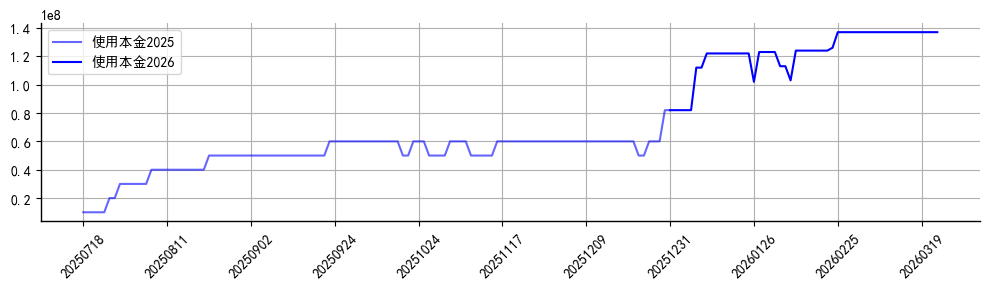

In [2]:
def plot_nom():
    save_path2 = r"D:\Github\chuangxintou\data.xlsx"

    df = pd.read_excel(save_path2)
    df = pd.DataFrame(df)
    # df['date'] = pd.to_datetime(df['日期'])
    df.rename(columns={'估值': 'PV', '日期':"date" , '名本':"nom"}, inplace=True)
    df['PV_DIFF'] = df['PV'].diff()
    df.loc[0, 'PV_DIFF'] = 0


    times_str = []
    tt = df['date']
    for t in tt:
        times_str.append(t.strftime('%Y%m%d'))
    # 查找特定日期
    target_date = '20251231'  # 要寻找的日期
    if target_date in times_str:
        index = times_str.index(target_date)
        found_date = df['date'].iloc[index]
        print(f"找到日期: {found_date}")
    else:
        print("未找到日期 2025-12-31")


    fig = plt.figure(figsize=( 10, 3 ))
    gs = GridSpec(nrows=1, ncols=1)#, width_ratios=[3, 1, 1, 0], height_ratios=[1, 1])
        
    # 第一个子图：绘制 qdt 列的散点图

    ax1 = fig.add_subplot(gs[0, 0])  # 第一行，占据前 3 列ax3 = fig.add_subplot(2,1)


    # cumulative_sum = result_df['qdt'].cumsum()  # 计算积分    
    data =np.array( df['nom'])
    # print('近一个月累积收益：' , data[-1])
    ax1.plot(times_str[:index+1], data[:index+1], 'b',alpha = 0.6,  label='使用本金2025')
    ax1.plot(times_str[index:], data[index:], 'b',  label='使用本金2026')


    itv = int(len(df)/10)
    if len(df)>63:
        pass
    else:
        itv =1
    # 设置每 60 个数据点一个 xtick
    ax1.set_xticks(times_str[::itv])
    ax1.set_xticklabels(times_str[::itv], rotation=45)
    ax1.legend()
    ax1.grid(True)

    # 设置背景色和边框
    plt.gca().patch.set_facecolor('#ffffff')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.gca().spines['left'].set_linewidth(1)

    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'IMAGES\\nom_plot.png'), dpi=300)


plot_nom()

,历史行情,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,估值总和
0,2025-07-22,2792.1823,4118.9582,6213.4072,6637.1035,NaN,0,0,0,68300.469939,NaN,6.830047e+04
1,2025-07-23,2801.2002,4119.7685,6196.7577,6607.22,NaN,0,0,0,57068.686016,NaN,5.706869e+04
2,2025-07-24,2812.4428,4149.0368,6293.5984,6701.12,NaN,0,0,0,108276.029891,NaN,1.082760e+05
3,2025-07-25,2795.5127,4127.1634,6299.5908,6706.6098,NaN,0,0,0,115011.330124,NaN,1.150113e+05
4,2025-07-28,2802.7674,4135.8242,6323.4198,6729.979,NaN,0,0,0,148096.693675,NaN,1.480967e+05
...,...,...,...,...,...,...,...,...,...,...,...,...
223,2026-06-25,2977.5696,5020.1038,8938.0113,8825.9201,NaN,0,0,2881016.438767,19139725.031461,NaN,2.202074e+07
224,2026-06-26,2906.9438,4868.2205,8703.5652,8601.4075,NaN,0,0,2881016.438767,17844514.455101,NaN,2.072553e+07
225,2026-06-29,2991.0809,4926.921,8821.0944,8597.8932,NaN,0,0,2881016.438767,17908791.75854,NaN,2.078981e+07
226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


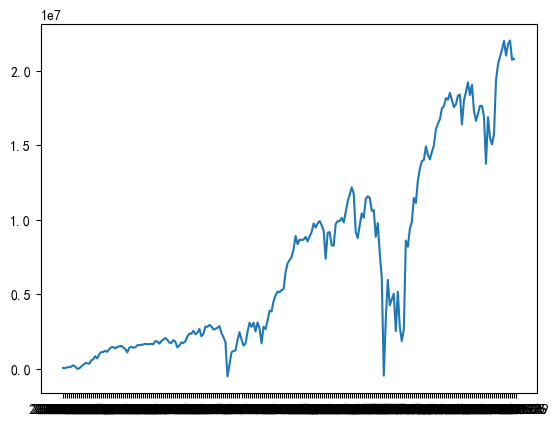

In [3]:
save_path2 = r"D:\Github\chuangxintou\创新投雪球管理.xlsx"
df1 = pd.read_excel(save_path2, sheet_name='合约状态')
# print(df1.head())
df2  = pd.read_excel(save_path2, sheet_name='历史行情')
df2 = df2.drop(df2.index[0:5]).reset_index(drop=True)
df2 = pd.DataFrame(df2)

# print(df2['历史行情'].dtype)

df2['历史行情'] = pd.to_datetime(df2['历史行情'], errors='coerce').dt.strftime('%Y-%m-%d')


# print(df2.head())
times_str = []
tt = df2['历史行情']
for t in tt:
    times_str.append(t)
plt.plot(times_str, df2['估值总和'])
df2


In [4]:
import sys
print(sys.executable)
print(sys.version)
import sys
import numpy as np
import matplotlib.pyplot as plt
import time
import datetime
# 添加指定路径到 sys.path
sys.path.append('D:\\Quotation\\build\\release\\python')

# 现在可以导入 fleet 包
import fleet

# 测试导入是否成功
print(f"The package 'fleet' is located at: {fleet.__file__}")
from fleet import *
import fleet as ft
cal = ft.Calendar("D:\\Quotation\\China")
CAL = ft.Calendar("D:\\Quotation\\China")
import pandas as pd

e:\Software\Anaconda\envs\plot_iv\python.exe
3.12.8 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:48:34) [MSC v.1929 64 bit (AMD64)]
The package 'fleet' is located at: D:\Quotation\build\release\python\fleet.cp312-win_amd64.pyd


In [5]:
start_date = ft.Date("2020-01-01")
import numpy as np
start = 1
step = 0.005
count = 24

# 生成干净、没有一堆9的数列 ✅
nums = [round(start - i * step, 3) for i in range(count)]

print(nums)

[1.0, 0.995, 0.99, 0.985, 0.98, 0.975, 0.97, 0.965, 0.96, 0.955, 0.95, 0.945, 0.94, 0.935, 0.93, 0.925, 0.92, 0.915, 0.91, 0.905, 0.9, 0.895, 0.89, 0.885]


In [6]:
time_start = time.time()    

start_date = ft.Date("2026-2-26")
value_date = ft.Date(2026, 2, 26)
print(start_date)

end_date = cal.ModifiedBusinessDay(start_date + ft.Period(2, ft.YEAR), ft.BusinessDayConvention.FOLLOWING)

ko_dates = cal.Schedule(start_date,end_date, ft.Period(1, ft.MONTH), 3, ft.BusinessDayConvention.FOLLOWING, ft.Direction.FORWARD)

# obser_dates  = ko_dates
obser_dates  = cal.Schedule(start_date,end_date, ft.Period(1, ft.DAY), 0 ,ft.BusinessDayConvention.FOLLOWING, ft.Direction.FORWARD)
print(len(obser_dates), obser_dates[-1])
# print(ko_dates)
ko_levels = [1.0]*len(ko_dates)

maturity_coupon = 0.1971

ko_coupons =[0.1971]*len(ko_dates)

initial_price = 8490.62
price = [8490.62] # 7639.376

norminal_principal = 10000000

ki_level = 0.70
ki_strike_level = 1.0
ki_participation = 1.0
is_daily_ki = True

margin_ratio = 1.

max_loss = 1.0

day_fraction_to_market_close =  0.

extra_ann = 0.0
extra_abs = 0.0

ann_calc_extra_business_days = 0.0
both_included = True
is_knock_in = False
rf = 0.021
q = -0.05783
vol = 0.19
greeks = {ft.GreekType.DELTA, ft.GreekType.GAMMA, ft.GreekType.VEGA, ft.GreekType.THETA, ft.GreekType.RHO, ft.GreekType.CARRY_RHO, ft.GreekType.DDELTADVOL,ft.GreekType.DDELTADQ}

res = ft.ValuateSnowball(cal, initial_price, start_date, ko_dates, ko_levels, 
                         ko_coupons, maturity_coupon, ki_level, ki_strike_level, ki_participation, 
                         is_daily_ki, margin_ratio, max_loss, extra_ann, extra_abs, 
                         ann_calc_extra_business_days, both_included, value_date, day_fraction_to_market_close, price,
rf,
q,
vol,
is_knock_in,
greeks)

print("PV", res[ft.PV][0] * norminal_principal / initial_price)
print("NPV", res[ft.PV][0] * norminal_principal / initial_price - norminal_principal * margin_ratio)
print("DELTA",res[ft.DELTA][0])

# res = ft.ValuateSnowball(cal, 1, start_date, ko_dates, ko_levels, ko_coupons, maturity_coupon, ki_level, ki_strike_level, ki_participation, is_daily_ki,
# margin_ratio, max_loss, extra_ann, extra_abs, ann_calc_extra_business_days, both_included,
# aa,
# ko_par_rate,
# [1.],
# rf,
# q,
# vol_quote,
# False,
# greeks)
# print(res[ft.PV][0] -norminal_principal , maturity_coupon)
# print(res[ft.DELTA][0])


time_end = time.time()
time_hedge = time_end - time_start
# print(time_hedge)
# print("Hedging time:", "%.3f" % time_hedge, "seconds", "%.3f"%(time_hedge/60), "minutes","%.3f"%float(time_hedge/3600), "hours")

2026-02-26
487 2028-02-28
PV 10000092.899507798
NPV 92.89950779825449
DELTA 0.5608709974250422


In [7]:
from scipy.optimize import fsolve

# ======================
# 你的函数（你自己的）
# ======================
def your_real_func(cal, initial_price, start_date, ko_dates, ko_levels, 
                        array_x, x, ki_level, ki_strike_level, ki_participation, 
                        is_daily_ki, margin_ratio, max_loss, extra_ann, extra_abs, 
                        ann_calc_extra_business_days, both_included, value_date, day_fraction_to_market_close, price,
                        rf,
                        q,
                        vol,
                        is_knock_in,
                        greeks):
    # array_x 是一整组 [x, x, x, ...] 这样相同的数
    res = ft.ValuateSnowball(cal, initial_price, start_date, ko_dates, ko_levels, 
                        array_x, x, ki_level, ki_strike_level, ki_participation, 
                        is_daily_ki, margin_ratio, max_loss, extra_ann, extra_abs, 
                        ann_calc_extra_business_days, both_included, value_date, day_fraction_to_market_close, price,
                        rf,
                        q,
                        vol,
                        is_knock_in,
                        greeks)
    return res[ft.PV][0] * norminal_principal / initial_price - norminal_principal * margin_ratio  # 你自己的计算逻辑


# ======================
# 构造求根方程（关键）
# ======================
def equation(x):
    # 构造 array_x = 一组全是 x 的数组（比如24个）
    array_x = [x] * len(ko_dates)
    # 调用你的函数，让结果 = 0
    return your_real_func(
        cal, initial_price, start_date, ko_dates, ko_levels,  array_x, x,
                        ki_level, ki_strike_level, ki_participation, 
                        is_daily_ki, margin_ratio, max_loss, extra_ann, extra_abs, 
                        ann_calc_extra_business_days, both_included, value_date, day_fraction_to_market_close, price,
                        rf, q, vol, is_knock_in, greeks
    )


# ======================
# 解方程！
# ======================
result = fsolve(equation, x0=1.0)  # x0 是猜一个初始值，比如1.0

print("解出来的 x =", result[0])

C:\Users\ZHI SHEN\AppData\Local\Temp\ipykernel_19076\837882696.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res = ft.ValuateSnowball(cal, initial_price, start_date, ko_dates, ko_levels,


解出来的 x = 0.19707905184414767
